# Tutorial: the leaky-integrator ESN

The reservoir update of the `EchoStateNetwork` supports a **leak rate** $\alpha$ (`leak_rate`):

$$
\bm{r}_{n+1} = (1-\alpha)\,\bm{r}_n
+ \alpha\tanh\!\left(\sigma_\mathrm{in}\bm{W}_\mathrm{in}[\bm{u}_n; b_\mathrm{in}]
+ \rho\,\bm{W}\bm{r}_n\right).
$$

The default $\alpha = 1$ is the plain $\tanh$ update -- **no leak** -- so existing
models are unchanged. With $\alpha < 1$ each neuron becomes a leaky integrator: the
update low-pass filters the reservoir, slowing its internal timescale. This matters
when the data is sampled much finer than its dynamics evolve -- a plain-tanh
reservoir then churns through its memory hundreds of steps per signal timescale,
while a leaky one can be tuned to match it.

This tutorial shows both ways to use it:

1. set `leak_rate` directly and sweep it,
2. add `'leak_rate'` to `hyperparameters_to_optimize` and let the Bayesian
   hyperparameter search tune it like `rho` and `sigma_in`.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

from echostatenetwork import EchoStateNetwork

## An oversampled Lorenz 63 dataset

Same system as the [`EchoStateNetwork` class tutorial](01_echo_state_network.ipynb),
but sampled four times finer: $\mathrm{d}t = 0.005$ with `upsample=1`, i.e.
$\approx 220$ ESN steps per Lyapunov time ($\lambda_1 \approx 0.906$). At this
sampling the input barely changes between consecutive steps -- the regime where the
leak earns its keep.


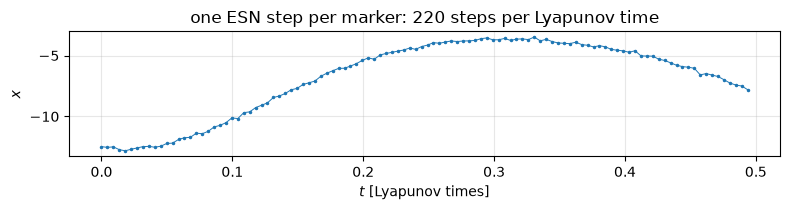

In [2]:
T_LYAP = 1 / 0.906                    # Lyapunov time of the Lorenz 63 system
DT = 0.005                            # 4x finer than the class tutorial
N_LYAP = int(T_LYAP / DT)             # ESN steps per Lyapunov time


def lorenz63(dt, n_lyap_times, noise_level=0.01, seed=0):
    """Noisy and clean Lorenz 63 trajectories on the attractor."""
    def rhs(t, u):
        return [10 * (u[1] - u[0]), u[0] * (28 - u[2]) - u[1],
                u[0] * u[1] - 8 / 3 * u[2]]
    t_end = (n_lyap_times + 10) * T_LYAP
    sol = solve_ivp(rhs, [0, t_end], [1., 1., 1.], t_eval=np.arange(0, t_end, dt),
                    method='RK45', rtol=1e-9)
    clean = sol.y.T[int(10 * T_LYAP / dt):]          # discard the transient
    rng = np.random.default_rng(seed)
    return clean + noise_level * clean.std(axis=0) * rng.standard_normal(clean.shape), clean


noisy, clean = lorenz63(DT, 75)
N_train, N_val = 55 * N_LYAP, 5 * N_LYAP
train_val_data = noisy[:N_train + 2 * N_val]
test_clean = clean[N_train + 2 * N_val:]

fig, ax = plt.subplots(figsize=(8, 2.2), layout='tight')
n_show = N_LYAP // 2
ax.plot(np.arange(n_show) * DT / T_LYAP, noisy[:n_show, 0], '.-', ms=3, lw=0.7)
ax.set(xlabel='$t$ [Lyapunov times]', ylabel='$x$',
       title=f'one ESN step per marker: {N_LYAP} steps per Lyapunov time')
ax.grid(alpha=0.3)
plt.show()

## Closed-loop forecast helpers

A forecast is initialised **open loop** -- the reservoir is washed out on `N_wash`
true snapshots -- and then run **closed loop**, feeding each prediction back as the
next input. The prediction horizon is the time until the normalized error first
exceeds a threshold, in Lyapunov times.


In [3]:
def closed_loop(esn, wash, n_steps):
    """Washout on true history, then an n_steps closed-loop forecast."""
    r = np.zeros((esn.N_units, 1))
    for u_in in wash:
        _, r = esn.step(u_in[:, None], r)
    u, U = wash[-1][:, None], []
    for _ in range(n_steps):
        u, r = esn.step(esn.outputs_to_inputs(u), r)
        U.append(u[:, 0])
    return np.array(U)


def horizon(esn, test, n_starts=5, threshold=0.2, n_fc=8 * N_LYAP):
    """Mean prediction horizon [Lyapunov times] over n_starts forecasts."""
    std, hs = test.std(axis=0), []
    for s in range(n_starts):
        i0 = s * (len(test) // 2 // n_starts)
        truth = test[i0 + esn.N_wash:i0 + esn.N_wash + n_fc]
        U = closed_loop(esn, test[i0:i0 + esn.N_wash], len(truth))
        err = np.linalg.norm((U - truth) / std, axis=1) / np.sqrt(test.shape[1])
        above = np.flatnonzero(err > threshold)
        hs.append((above[0] if above.size else len(truth)) * DT / T_LYAP)
    return np.mean(hs)

## 1. Fixed leak rate: a sweep

One ESN per $\alpha$, each with its own Bayesian search over
$(\rho, \sigma_\mathrm{in}, \lambda)$ so every leak rate competes with its best
supporting hyperparameters. `training_summary()` reports `leak_rate` whenever it
differs from 1.


In [4]:
ESN_PARAMS = dict(N_wash=50, N_units=100, upsample=1, seed=1,
                  t_train=N_train * DT, t_val=N_val * DT, t_test=0.,
                  N_func_evals=12, N_grid=3, noise=1e-2, N_folds=6, 
                  rho_range=(.2, 1.0), sigma_in_range=(-3, 0),
                  tikh_range=[1e-9, 1e-11])

alphas = [1.0, 0.5, 0.2, 0.05]
esns, horizons = {}, {}
for alpha in alphas:
    esn = EchoStateNetwork(train_val_data.T, dt=DT, leak_rate=alpha,
                           hyperparameters_to_optimize=['rho', 'sigma_in', 'tikh'],
                           **ESN_PARAMS)
    esn.train(train_val_data, plot_training=False)
    esns[alpha], horizons[alpha] = esn, horizon(esn, test_clean)
    print(f'alpha={alpha}: horizon = {horizons[alpha]:.2f} Lyapunov times')

seed 1 	 Optimal hyperparameters: [0.31245764958867167, -0.13954975249649682], 1e-09, MSE: -1.561706063974702


trained: 12100+1100 train+val steps, 1099 test | t_train=60.5, t_val=5.5 | rho=0.312, sigma_in=0.725, tikh=1e-09 | 6 validation folds | BHO: 12 evals over ['rho', 'sigma_in']


alpha=1.0: horizon = 2.53 Lyapunov times


seed 1 	 Optimal hyperparameters: [0.3848491958318175, 0.0], 1e-09, MSE: -1.5513839372633527


trained: 12100+1100 train+val steps, 1099 test | t_train=60.5, t_val=5.5 | rho=0.385, sigma_in=1, tikh=1e-09, leak_rate=0.5 | 6 validation folds | BHO: 12 evals over ['rho', 'sigma_in']


...

trained: 12100+1100 train+val steps, 1099 test | t_train=60.5, t_val=5.5 | rho=0.2, sigma_in=0.706, tikh=1e-11, leak_rate=0.2 | 6 validation folds | BHO: 12 evals over ['rho', 'sigma_in']


alpha=0.2: horizon = 3.20 Lyapunov times


seed 1 	 Optimal hyperparameters: [0.4149745259557616, 0.0], 1e-11, MSE: -1.0139698279445526


trained: 12100+1100 train+val steps, 1099 test | t_train=60.5, t_val=5.5 | rho=0.415, sigma_in=1, tikh=1e-11, leak_rate=0.05 | 6 validation folds | BHO: 12 evals over ['rho', 'sigma_in']


alpha=0.05: horizon = 0.01 Lyapunov times


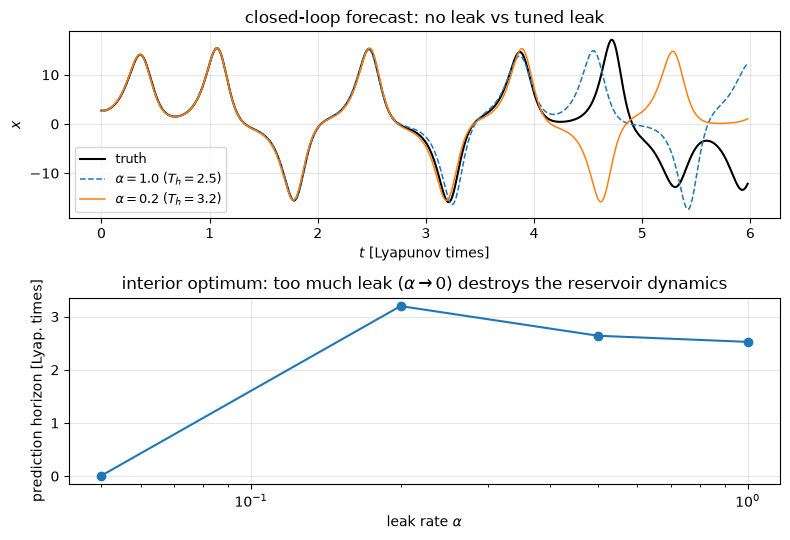

In [5]:
i0 = 0
truth = test_clean[i0 + 50:i0 + 50 + 6 * N_LYAP]
t_fc = np.arange(len(truth)) * DT / T_LYAP

fig, axs = plt.subplots(2, 1, figsize=(8, 5.5), layout='tight')
axs[0].plot(t_fc, truth[:, 0], 'k', lw=1.5, label='truth')
for alpha, ls in [(1.0, '--'), (0.2, '-')]:
    U = closed_loop(esns[alpha], test_clean[i0:i0 + 50], len(truth))
    axs[0].plot(t_fc, U[:, 0], ls, lw=1.1,
                label=f'$\\alpha={alpha}$ ($T_h={horizons[alpha]:.1f}$)')
axs[0].set(xlabel='$t$ [Lyapunov times]', ylabel='$x$',
           title='closed-loop forecast: no leak vs tuned leak')
axs[0].legend(fontsize=9)

axs[1].semilogx(alphas, [horizons[a] for a in alphas], 'o-')
axs[1].set(xlabel=r'leak rate $\alpha$', ylabel='prediction horizon [Lyap. times]',
           title=r'interior optimum: too much leak ($\alpha \to 0$) '
                 'destroys the reservoir dynamics')
for ax in axs:
    ax.grid(alpha=0.3)
plt.show()

## 2. Optimizing the leak rate in the Bayesian search

Add `'leak_rate'` to `hyperparameters_to_optimize` -- the search range is
`leak_rate_range` (default $(0.1, 1)$, overridable like `rho_range`). With four
dimensions the search needs a larger evaluation budget than the three-parameter
runs above. `bo_results` keeps the evaluated points, so the search over
$\alpha$ can be inspected afterwards.



 ----------------- HYPERPARAMETER SEARCH ------------------
 3^3 grid and 3 points with Bayesian Optimization
		 rho	 sigma_in	 tikh	 leak_rate	 MSE val 


1	 2.000e-01	 1.000e-03	 1.000e-09	 1.000e-01	 -0.8092


2	 2.000e-01	 1.000e-03	 1.000e-11	 5.500e-01	 -0.8495


3	 2.000e-01	 1.000e-03	 1.000e-11	 1.000e+00	 -0.8292


4	 2.000e-01	 3.162e-02	 1.000e-09	 1.000e-01	 1.5246


...

28	 4.473e-01	 3.162e-02	 1.000e-09	 7.531e-01	 -0.7285


29	 3.829e-01	 8.495e-01	 1.000e-09	 7.370e-01	 -1.4331


30	 7.190e-01	 5.366e-01	 1.000e-09	 6.600e-01	 -1.2460
seed 1 	 Optimal hyperparameters: [np.float64(0.2), np.float64(0.0), np.float64(0.55)], 1e-09, MSE: -1.498806961485408


trained: 12100+1100 train+val steps, 1099 test | t_train=60.5, t_val=5.5 | rho=0.2, sigma_in=1, tikh=1e-09, leak_rate=0.55 | 6 validation folds | BHO: 30 evals over ['rho', 'sigma_in', 'leak_rate']
trained: 12100+1100 train+val steps, 1099 test | t_train=60.5, t_val=5.5 | rho=0.2, sigma_in=1, tikh=1e-09, leak_rate=0.55 | 6 validation folds | BHO: 30 evals over ['rho', 'sigma_in', 'leak_rate']


horizon = 2.64 Lyapunov times


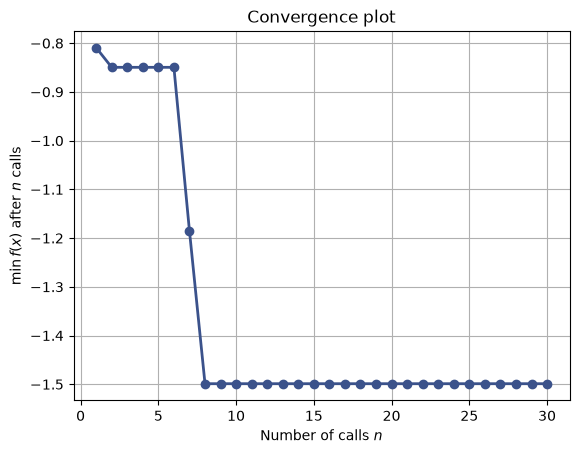

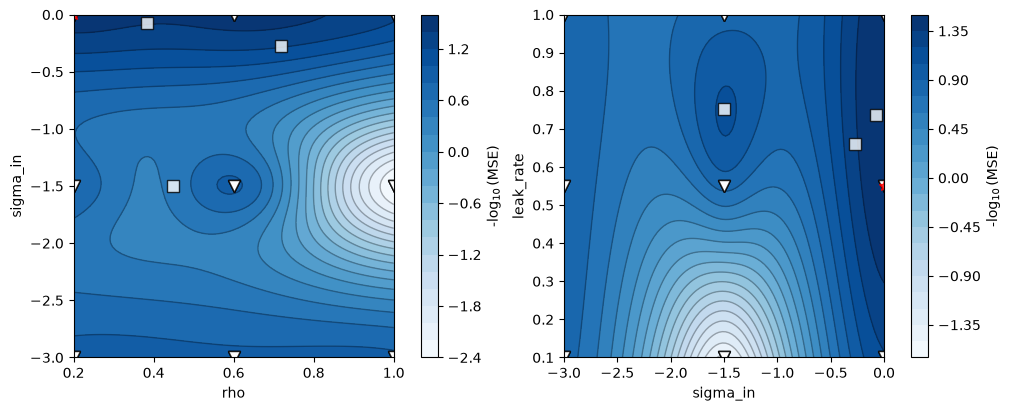

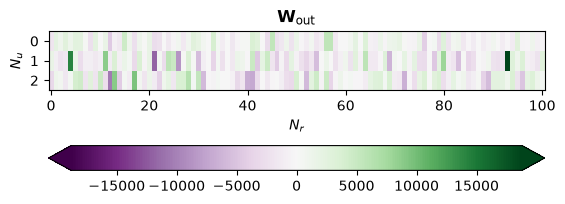

In [6]:
esn_bho = EchoStateNetwork(train_val_data.T, dt=DT,
                           hyperparameters_to_optimize=['rho', 'sigma_in',
                                                        'tikh', 'leak_rate'],
                           **{**ESN_PARAMS, 'N_func_evals': 30})
esn_bho.train(train_val_data, plot_training=True)
print(esn_bho.training_summary())
print(f'horizon = {horizon(esn_bho, test_clean):.2f} Lyapunov times')

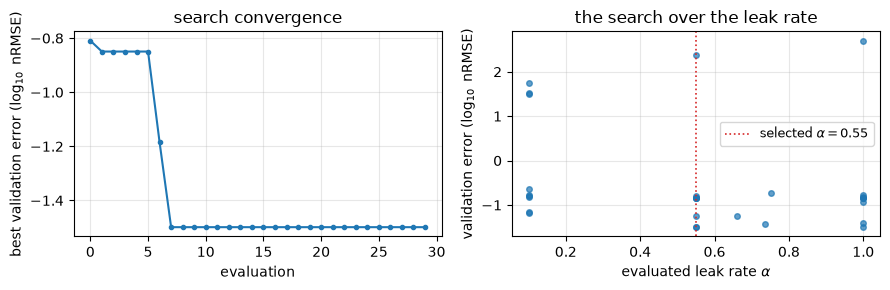

In [7]:
bo = esn_bho.bo_results
i_leak = bo['hp_names'].index('leak_rate')
leaks = [x[i_leak] for x in bo['x_iters']]

fig, axs = plt.subplots(1, 2, figsize=(9, 3), layout='tight')
axs[0].plot(np.minimum.accumulate(bo['func_vals']), 'o-', ms=3)
axs[0].set(xlabel='evaluation', ylabel=r'best validation error ($\log_{10}$ nRMSE)',
           title='search convergence')
axs[1].plot(leaks, bo['func_vals'], 'o', ms=4, alpha=0.7)
axs[1].axvline(esn_bho.leak_rate, color='tab:red', ls=':', lw=1.2,
               label=f'selected $\\alpha={esn_bho.leak_rate:.2f}$')
axs[1].set(xlabel=r'evaluated leak rate $\alpha$',
           ylabel=r'validation error ($\log_{10}$ nRMSE)', title='the search over the leak rate')
axs[1].legend(fontsize=9)
for ax in axs:
    ax.grid(alpha=0.3)
plt.show()

## Takeaways

- `leak_rate` $\alpha$ turns the reservoir into a leaky integrator;
  $\alpha = 1$ (the default) is the plain $\tanh$ update, so nothing changes
  unless you ask for it.
- The leak matters when the data is sampled much finer than its dynamics: it slows
  the reservoir to the signal's timescale. The optimum is interior -- $\alpha \to 0$
  over-smooths and the reservoir stops computing.
- Tune it by hand (`leak_rate=0.2`) or add `'leak_rate'` to
  `hyperparameters_to_optimize`; budget more `N_func_evals` for the extra search
  dimension, and adjust `leak_rate_range` to the sampling of your data.
